In [1]:
import torch
import torch_geometric

print(torch.__version__)
print(torch_geometric.__version__)

C:\Users\PC\anaconda3\envs\gnn\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2.12.0+cpu
2.8.0


In [5]:
from torch_geometric.datasets import Planetoid
# Зареждане на набора от данни
dataset = Planetoid(root='data/Cora', name='Cora')
print(dataset)

Processing...


Cora()


Done!


In [6]:
# Извличане на графа
data = dataset[0]
print(data)

Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])


In [7]:
print("Брой възли:", data.num_nodes)
print("Брой ребра:", data.num_edges)
print("Брой характеристики:", data.num_features)
print("Брой класове:", dataset.num_classes)

Брой възли: 2708
Брой ребра: 10556
Брой характеристики: 1433
Брой класове: 7


In [11]:
print(data.x.shape)
print(data.y.shape)
# характеристиките на първата публикация
print(data.x[0])
# класа на първия възел
print(data.y[0])

torch.Size([2708, 1433])
torch.Size([2708])
tensor([0., 0., 0.,  ..., 0., 0., 0.])
tensor(3)


In [13]:
# ребра
print(data.edge_index)
for i in range(10):
    source = data.edge_index[0][i]
    target = data.edge_index[1][i]

    print(f"{source} -> {target}")

tensor([[ 633, 1862, 2582,  ...,  598, 1473, 2706],
        [   0,    0,    0,  ..., 2707, 2707, 2707]])
633 -> 0
1862 -> 0
2582 -> 0
2 -> 1
652 -> 1
654 -> 1
1 -> 2
332 -> 2
1454 -> 2
1666 -> 2


In [40]:
# Брой думи, които присъстват в публикация с индекс 0 (от 1433 възможни думи)
print("Брой активни характеристики:", data.x[0].sum())

Брой активни признаци: tensor(9.)


In [37]:
# Съседи на възел
# Намиране на публикациите, които са свързани с възел 0.

neighbors = []

for i in range(data.edge_index.shape[1]):
    if data.edge_index[0][i] == 0:
        neighbors.append(
            data.edge_index[1][i].item())

print(neighbors)

[633, 1862, 2582]


In [33]:
# Изследване на графа
avg_degree = data.num_edges / data.num_nodes
print("Средна степен:", avg_degree)

density = data.num_edges / (data.num_nodes * (data.num_nodes - 1))
print("Плътност:", density)

# Самостоятелни възли
print(data.has_isolated_nodes())
# Самоцикли - връзки, които започват и завършват в един и същ възел.
print(data.has_self_loops())

Средна степен: 3.8980797636632203
Плътност: 0.0014399999126942077
False
False


In [19]:
from torch_geometric.utils import to_networkx
import networkx as nx
import matplotlib.pyplot as plt
# Преобразуване на графа в NetworkX
G = to_networkx(data, to_undirected=True)

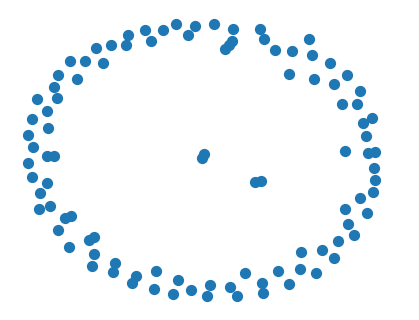

In [34]:
# Извличане на подграф
subgraph = G.subgraph(range(100))
# Визуализация
plt.figure(figsize=(4,3))
nx.draw(subgraph,
        node_size=50,
        with_labels=False)

plt.show()

In [ ]:
import sys
!{sys.executable} -m pip install torch

In [ ]:
import sys
!{sys.executable} -m pip install torch_geometric

In [4]:
import sys
!{sys.executable} -m pip install scipy

   ---------------------------------------- 0.0/36.6 MB ? eta -:--:--
   ------- -------------------------------- 6.6/36.6 MB 33.6 MB/s eta 0:00:01
   ---------------- ----------------------- 15.2/36.6 MB 36.8 MB/s eta 0:00:01
   ------------------------ --------------- 22.0/36.6 MB 36.6 MB/s eta 0:00:01
   ------------------------------ --------- 27.8/36.6 MB 33.9 MB/s eta 0:00:01
   -------------------------------------- - 34.9/36.6 MB 33.6 MB/s eta 0:00:01
   ---------------------------------------- 36.6/36.6 MB 31.9 MB/s  0:00:01


In [18]:
import sys
!{sys.executable} -m pip install matplotlib

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ----------------------------------- ---- 7.3/8.2 MB 34.9 MB/s eta 0:00:01
   ---------------------------------------- 8.2/8.2 MB 30.0 MB/s  0:00:00
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.4 MB ? eta -:--:--
   ---------------------------------------- 2.4/2.4 MB 44.6 MB/s  0:00:00
   ---------------------------------------- 0.0/7.1 MB ? eta -:--:--
   -------------------------------- ------- 5.8/7.1 MB 27.1 MB/s eta 0:00:01
   ---------------------------------------- 7.1/7.1 MB 27.3 MB/s  0:00:00

   ---------------------------------------- 0/6 [pillow]
   ---------------------------------------- 0/6 [pillow]
   ---------------------------------------- 0/6 [pillow]
   ---------------------------------------- 0/6 [pillow]
   ---------------------------------------- 0/6 [pillow]
   -----------